In [10]:
import stack_tools
import importlib

In [11]:
from scipy.special import erf
from scipy.optimize import curve_fit
from scipy.stats import lognorm
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib import cm
import numpy as np
from scipy.special import erfc, erfcx, log_ndtr
%matplotlib ipympl


In [12]:
no_marg = stack_tools._log_likelihood_ul(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))
marg = stack_tools._log_likelihood_ul_nuisance(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))

/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:157: RuntimeWarning: divide by zero encountered in log
  prior_vs_sigma = np.log(sigma_e[None,:] * ((sigma_data**2 + sigma_model**2)[:,None] + sigma_e[None,:]**2)**-1) # shape: (n_bursts, n_sigma_e)


In [13]:
%pdb on

Automatic pdb calling has been turned ON


In [59]:
def lognormal_from_moments(x,mean, std):
    """
    Given mean and variance moments, return a log-normal PDF with matching moments.
    
    For a log-normal distribution, if X ~ LogNormal(μ, σ²), then:
    - E[X] = exp(μ + σ²/2)
    - Var[X] = exp(2μ + σ²) * (exp(σ²) - 1)
    
    Solving for μ and σ:
    - σ² = ln(1 + variance/mean²)
    - μ = ln(mean) - σ²/2
    
    Parameters:
    -----------
    mean : float
        The desired mean of the distribution (must be positive)
    variance : float
        The desired variance of the distribution (must be positive)
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'mu': μ parameter of the log-normal distribution
        - 'sigma': σ parameter of the log-normal distribution
        - 'pdf': function that evaluates the PDF at given points
        - 'scipy_dist': scipy.stats lognorm object for additional methods
    
    Raises:
    -------
    ValueError: If mean or variance are not positive
    """
    
    if mean <= 0:
        raise ValueError("Mean must be positive for log-normal distribution")
    if std <= 0:
        raise ValueError("Variance must be positive")

    variance = std**2
    # Calculate log-normal parameters from moments
    sigma_squared = np.log(1 + variance / (mean**2))
    sigma = np.sqrt(sigma_squared)
    mu = np.log(mean) - sigma_squared / 2
    scipy_dist = lognorm(s=sigma, scale=np.exp(mu))
    return scipy_dist.pdf(x)

from scipy.interpolate import CubicSpline

def ll_convolved(x,mu1,sd1,mu2,sd2,mu3,sd3,num = 100):
    """Vectorized over mu3, sd3"""
    x = np.atleast_1d(x)
    common_grid = np.linspace(1e-200,np.max(x)*1.1,num = num)
    dx = common_grid[1]-common_grid[0]
    sum12_grid = np.arange(2 * len(common_grid) - 1) * dx
    sum123_grid = np.arange(3 * len(common_grid) - 2) * dx
    p1 = lognormal_from_moments(common_grid,mu1,sd1)
    p2 = lognormal_from_moments(common_grid,mu2,sd2)
    p12 = np.convolve(p1 / np.max(p1),p2 / np.max(p2)) * np.max(p1) * np.max(p2) / num

    mu3 = np.atleast_1d(mu3)
    sd3 = np.atleast_1d(sd3)
    ans = np.zeros((sd3.size,mu3.size,x.size))
    p123 = np.zeros_like(sum123_grid) + 1e-100
    for iimu3,_mu3 in enumerate(mu3):
        for iisd3,_sd3 in enumerate(sd3):
            p3 = lognormal_from_moments(common_grid,_mu3,_sd3)
            p123 += np.convolve(p12 / np.max(p12),p3 / np.max(p3)) * np.max(p12) * np.max(p3) / num
            if 0:
                plt.figure()
                plt.semilogx(common_grid,np.log(p1),label = mu1)
                plt.axvline(mu1)
                
                plt.plot(sum12_grid,np.log(p12))
                plt.axvline(mu1 + mu2)
                
                plt.plot(sum123_grid,np.log(p123))
                plt.axvline(mu1 + mu2 + _mu3)
            spl = CubicSpline(sum123_grid, np.log(p123))
            ans[iisd3,iimu3,:] = spl(x)
    return ans.squeeze()

def log_likelihood_hp_ln(df,res,weight_index = 2,verbose = False,sigma_cbm_arr = np.linspace(1,100,num = 10),
                                dm_cbm_arr = np.linspace(1,200, num = 30)):
    """Computes log likelihood with proper treatment of the hyperparameters (hence, 'hp' in the name).

    Returns an array whose shape is the same as ms."""
    msb = np.array(res['M_star_bins'])
    bin_centers = np.sqrt(msb[:,0] * msb[:,1])
    indices = np.zeros(len(df),dtype = int)
    for ii,_ms in enumerate(df['published_M*']):
        indices[ii] = np.argmin(np.abs(bin_centers - _ms))
    model = res['weighted_mean'][weight_index,[indices]].squeeze() # fix model weighting scheme, then choose correct bin to compare each data point against
    model_err = res['weighted_std'][weight_index,[indices]].squeeze() # fix model weighting scheme, then choose correct bin to compare each data point against
    dm_eg = np.array(df['DM'] - df['DM_NE2001'] - df['DM_YT20'])
    dm_cosmic = np.array(df['dm_igm']) # mislabeled as IGM but it's cosmic
    sigma_cosmic = dmh_tools.sigma_igm_walker2024(df['primary_z_spec'])
    dm_model = np.array(model)
    dm_model_err = np.array(model_err)
    ll_per_burst_logn = np.zeros((len(df),len(sigma_cbm_arr),len(dm_cbm_arr)))
    for ii in range(len(dm_eg)):
        print(ii)
        print(dm_cosmic[ii])
        print(sigma_cosmic[ii])
        print(dm_model[ii])
        print(dm_model_err[ii])
        if 1:
            ll_per_burst_logn[ii] = ll_convolved(dm_eg[ii],
                                             mu1 = dm_cosmic[ii], 
                                             sd1 = sigma_cosmic[ii],
                                             mu2 = dm_model[ii], 
                                             sd2 = dm_model_err[ii], 
                                             mu3 = dm_cbm_arr, 
                                             sd3 = sigma_cbm_arr)
        
    return ll_per_burst_logn


In [60]:

import pandas as pd
import dmh_tools,camels_tools
import os

models = ['Astrid','IllustrisTNG','SIMBA']
variants = [
    ['Apples (z=0.1)',('086',0.13,0.20,2,'same_sigmacgm')],
    ['Fiducial (z=0.1)',('086',0.13,0.20,2,'fid0.1')],
    #['Fiducial (z=0.0)',('090',0.13,0.20,2,'fid0')],
    #['Fiducial (z=0.2)',('082',0.13,0.20,2,'fid0.2')],
    #[r'$0.10 < b < 0.20$',('086',0.1,0.2,2,'lowb')],
    #[r'$0.10 < b < 0.16$',('086',0.1,0.16,2,'highb')],
    #[r'P(O|x) > 0.95',('086', 0.13, 0.20,2,'goldgold')],
    #[r'Weighting $\propto M^*$',('086',0.13,0.2,1)],
    #[r'Weighting $\propto SFR \times M^*$',('086',0.13,0.2,3)],
    #['Uniform weight' ,('086',0.13,0.20,0)],
    #[r'$\langle DM_{cosmic} \rangle$ +50%',('086',0.13,0.20,2,'high_igm')],
    #[r'$\langle DM_{cosmic} \rangle$ -50%',('086',0.13,0.20,2,'low_igm')],
    #[r'1.5 $\times\sigma_\mathrm{cosmic}$',('086',0.13,0.20,2,'inflate_sigma_cosmic')],
    #[r'Varying $\sigma_\mathrm{cosmic}$',('086',0.13,0.20,2,'varying_sigma_cosmic')],
    #[r'Low end only ($M^* < 10^{9.8}$)',('086', 0.13, 0.20,2,'low')],
    #[r'High end only ($M^* > 10^{9.8}$)',('086', 0.13, 0.20,2,'high')],
    #[r'All $M^*$ -0.3 dex',('086', 0.13, 0.20,2,'low_mstar')],
    #[r'Knockout',('086', 0.13, 0.20,2,'knockout')],
    #[r'Zero model',('086', 0.13, 0.20,2,'null_model')],
    [r'No data',('086', 0.13, 0.20,2,'no_data')],
]
ROOT_PATH = os.getcwd() + '/../'


In [61]:

sigma_cbm_arr = np.linspace(10,200,num = 24)  #np.linspace(1,100,num = 1)
dm_cbm_arr = np.linspace(10,100,num = 20) #np.linspace(0,200, num = 1)
ll_per_variant_model_burst = np.zeros((len(variants),3,len(df),len(sigma_cbm_arr),len(dm_cbm_arr)))
ll_per_variant = np.zeros((3,len(variants)))
import importlib

for iivariant,(variant_name,params) in enumerate(variants):
    _df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
    _df.set_index('name',inplace=True)
    keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
    df = _df[keep]
    plot_mstar = df['published_M*']
    plot_dm = df['DM_host_restframe']
    plot_dmerr = dmh_tools.sigma_tot(df)
    for iimodel,model in enumerate(models):
        keep = dmh_tools.not_low_dm(df) * dmh_tools.not_scattered(df) * dmh_tools.not_clusters(df) * dmh_tools.not_edge_on(df) * dmh_tools.not_dwarf(df) * dmh_tools.not_elliptical(df) 
        # analysis perturbations
        vary_igm_factor = 0
        model_mult = 1
        model_err_mult = 1
        model_err_offset = 0
        data_err_mult = 1
        mstar_bias_dex = 0.0    
        try:
            (snap_id, b_min, b_max, iiweight,variant) = params
        except:
            (snap_id, b_min, b_max, iiweight) = params
        if variant == 'same_sigmacgm':
            model_err_mult = 0
            model_err_offset = 70 # take a scatter of 70 pc cm-3
        if variant == 'low':
            keep = df['published_M*'] < 9.8
        elif variant == 'high':
            keep = df['published_M*'] >= 9.8
        elif variant == 'low_igm':
            vary_igm_factor = -0.5
        elif variant == 'high_igm':
            vary_igm_factor = 0.5
        elif variant == 'goldgold':
            keep = keep * np.isnan(df['primary_P_Ox']) + (df['primary_P_Ox'] > 0.95)
        elif variant == 'null_model':
            model_mult = 0
        elif variant == 'varying_sigma_cosmic':
            if model == 'SIMBA':
                data_err_mult = 0.8
            if model == 'Astrid':
                data_err_mult = 1.5
            if model == 'IllustrisTNG':
                data_err_mult = 1.0
        elif variant == 'inflate_sigma_cosmic':
            data_err_mult = 1.5
        elif variant == 'low_mstar': # if we overestimate our stellar masses
            mstar_bias_dex = -0.3
        elif variant == 'no_data':
            data_err_mult = 100
        redshift_str = f"z = {camels_tools.CAMELS_REDSHIFTS[snap_id]:.2f}"
        snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
        stack_path = f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/{model}_1P_3_0_snap{snap_id}_haloDM' + f'_bminmax={b_min:.2f}_{b_max:.2f}.h5'
        results = camels_tools.from_file(stack_path)
        results['weighted_mean'] *= model_mult
        results['weighted_mean'] *= model_mult
        results['weighted_std'] *= model_err_mult
        results['weighted_std'] += model_err_offset
        if 0:
            ll_per_variant_model_burst[iivariant,iimodel,keep] = stack_tools.log_likelihood_hp_gauss(
                ms = (plot_mstar * 10**(mstar_bias_dex))[keep],
                dm = ((plot_dm + vary_igm_factor * df['dm_igm']))[keep],
                dm_err = ((plot_dmerr * data_err_mult))[keep],
                res=results,
                sigma_cbm_arr = sigma_cbm_arr,
                dm_cbm_arr = dm_cbm_arr,
                weight_index = iiweight)
        if 1:
            ll_per_variant_model_burst[iivariant,iimodel,keep] = log_likelihood_hp_ln(
                df[keep],
                res = results,
                weight_index = 2,
                verbose = False,sigma_cbm_arr = sigma_cbm_arr,
                                dm_cbm_arr = dm_cbm_arr)


0
99.88203576888128
70.69412
59.131758046261766
70.0
1
137.60162389500144
88.55632
59.131758046261766
70.0
2
39.119796548974165
29.687699999999992
59.131758046261766
70.0
3
59.994432597171354
45.25949999999999
59.131758046261766
70.0
4
109.93572052303652
75.47121999999999
59.131758046261766
70.0
5
64.78696502082293
48.80429999999999
59.131758046261766
70.0
6
165.78408315243536
101.76603999999999
59.131758046261766
70.0
7
134.23936299255027
86.9778
59.131758046261766
70.0
8
134.1508824424858
86.93626
59.131758046261766
70.0
9
19.639944942542215
14.993237999999996
59.131758046261766
70.0
10
135.33563700784947
87.4924806
59.131758046261766
70.0
11
93.12910154093254
67.454
59.131758046261766
70.0
12
46.22201183003261
35.00489999999999
59.131758046261766
70.0
13
65.81572487656828
49.56389999999999
59.131758046261766
70.0
14
61.18630552571421
46.1457
59.131758046261766
70.0
15
91.3124592319318
66.58166
59.131758046261766
70.0
16
100.93111591714094
71.1926
59.131758046261766
70.0
17
89.582323

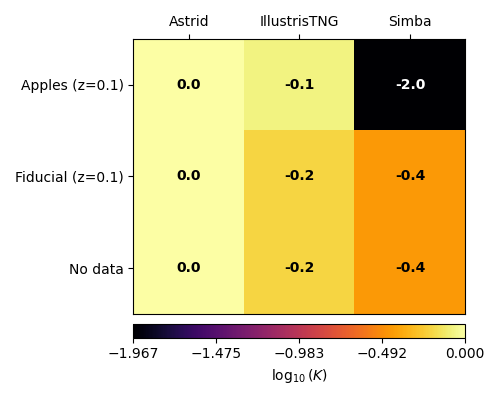

In [62]:
prior = (dm_cbm_arr > 0)[None,:] + (1/sigma_cbm_arr)[:,None]
ll_per_variant_model_burst[np.isnan(ll_per_variant_model_burst)] = -np.inf
for iivariant,(variant_name,params) in enumerate(variants):
    ll_per_variant[:,iivariant] = stack_tools.marginalize_ll_hp(
                                        ll_per_variant_model_burst[iivariant],
                                        prior,
                                        dm_cbm_arr,
                                        sigma_cbm_arr,
                                    )
fig = plt.figure(figsize = (5,4))
#plt.title(r'Bayes')
stack_tools.plot_fig2(fig,plt.gca(),ll_per_variant * np.log10(np.e), cmap = 'inferno',xnames = ['Astrid','IllustrisTNG','Simba'], 
    ynames = np.array([v[0] for v in variants]), cbar_label = r'$\log_{10}(K)$',
)
plt.tight_layout()

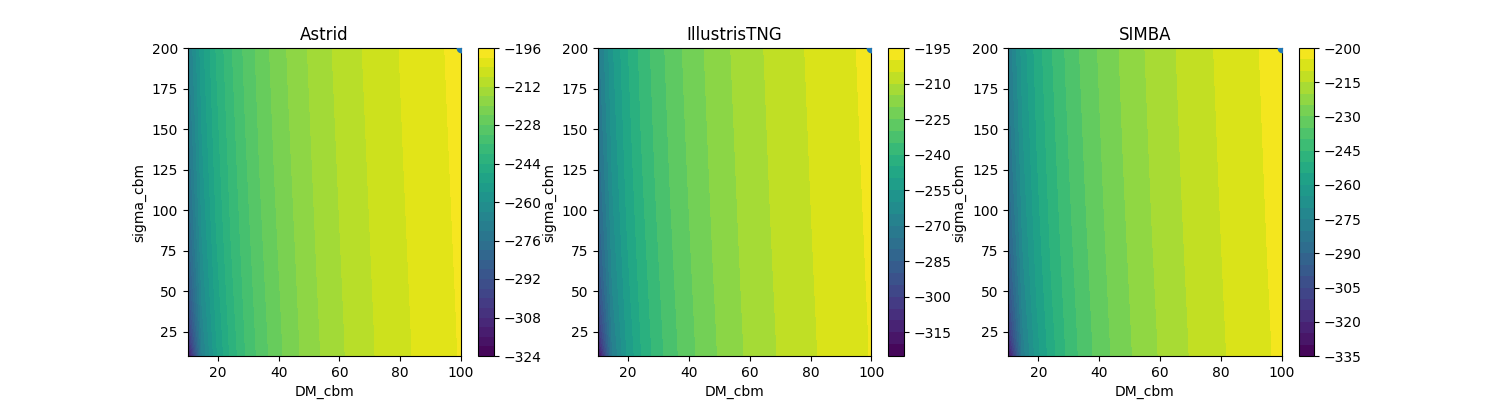

In [58]:
def find_argmax(x,y,xy):
    shape = xy.shape
    iy,ix = np.unravel_index(np.argmax(xy.flat),shape)
    return x[ix],y[iy]
plt.figure(figsize = (15,4))

for iimodel,model in enumerate(models):
    plt.subplot(130+iimodel+1)
    plt.title(model)
    ans = np.log(prior) + np.sum(ll_per_variant_model_burst,axis = 2)[0,iimodel]
    x,y = find_argmax(dm_cbm_arr,sigma_cbm_arr,ans)
    plt.scatter(x,y,zorder = 10)
    plt.contourf(dm_cbm_arr,sigma_cbm_arr,ans,levels = 30)
    plt.xlabel('DM_cbm')
    plt.ylabel('sigma_cbm')
    plt.colorbar()


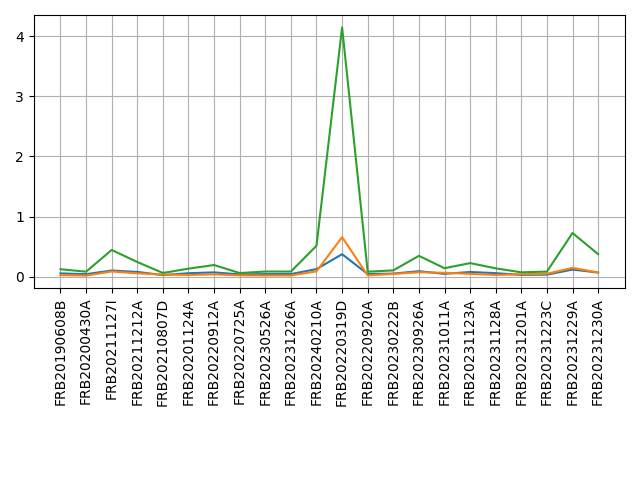

In [117]:
plt.figure()
plt.plot(df.index,(np.max(np.abs(ll_per_variant_model_burst[3] - ll_per_variant_model_burst[0]),axis = (-2,-1))).T)
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.4)

# Check the integral

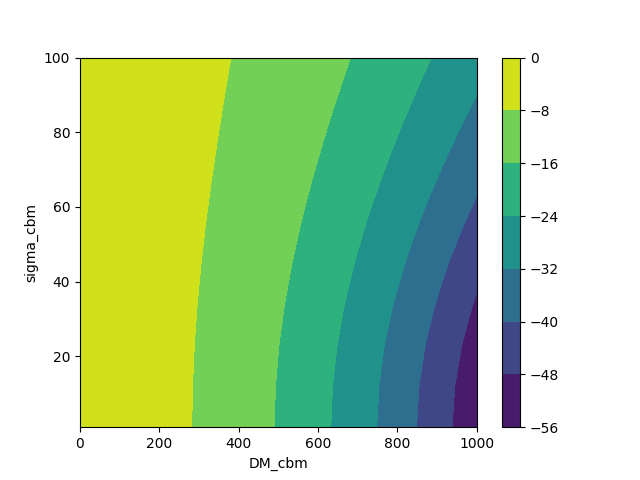

In [146]:
sigma_cbm_arr = np.linspace(1,100,num = 10)
dm_cbm_arr = np.linspace(0,1000)
ans = stack_tools.log_likelihood_mgaussian(dm_host_restframe = 100, sigma_i = 100, 
                                                  dm_model = 100,sigma_cbm_arr = sigma_cbm_arr, 
                                                  dm_cbm_arr=dm_cbm_arr).squeeze()
plt.figure()
plt.contourf(dm_cbm_arr,sigma_cbm_arr,ans)
plt.xlabel('DM_cbm')
plt.ylabel('sigma_cbm')
plt.colorbar()


In [168]:
from scipy.stats import lognorm

In [293]:

log_likelihood_hp_gauss(df,res

NameError: name 'res' is not defined

> /var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_33111/2003052792.py(1)<module>()
----> 1 res



ipdb>  q
